<div style="width:100vw; margin-left:-50vw; left:50%; position:relative;">
  <img src="https://i.postimg.cc/MTBpfsYw/CURSO-PYTHON-SIMPEG.png" style="width:100%;">
</div>

# FWI: Implementación con pesos preentrenados

Este notebook organiza el flujo de evaluación de **modelos preentrenados** para inversión sísmica 2D dentro de OpenFWI.

En esta versión se trabaja principalmente con **InversionNet** y **VelocityGAN**, utilizando directamente los datos y configuraciones ya definidos en el código original.



<div style="width:100vw; margin-left:-50vw; left:50%; position:relative;">
  <img src="https://i.postimg.cc/RV8t9X5t/Chat-GPT-Image-28-jul-2026-01-53-44-p-m.png" style="width:100%;">
</div>

## Organización del notebook

El desarrollo se divide en los siguientes bloques:

1. **Preparación del entorno**: conexión con Google Drive e importación de librerías.
2. **Configuración de rutas**: definición de carpetas para pesos preentrenados y resultados.
3. **Evaluación con InversionNet**: pruebas sobre las familias **CurveVel** y **FlatFault**, cada una con modelos entrenados usando pérdidas **L2 (MSE)** y **L1 (MAE)**.
4. **Espacio reservado para VelocityGAN**: sección preparada para futuras pruebas con otra arquitectura.


---

## 1. Preparación del entorno

En esta sección se monta Google Drive, se accede a la carpeta de trabajo y se importan utilidades básicas para la visualización de resultados.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/OpenFWI

/content/drive/MyDrive/OpenFWI


In [ ]:
from IPython.display import Image
from IPython.display import display

---

## 2. Configuración de rutas de trabajo

Aquí se define la carpeta compartida del proyecto y la carpeta personal donde se guardarán las salidas generadas durante la inferencia.


In [ ]:
#@title Configuración de las rutas de trabajo
#@markdown Esta celda configura una carpeta personal para guardar las predicciones y visualizaciones generadas durante la práctica, sin modificar la carpeta compartida del curso.
#@markdown
#@markdown Los pesos preentrenados se leen desde la carpeta compartida de OpenFWI y los resultados se guardan en el Drive personal de cada estudiante.
#@markdown
#@markdown **Ejecuta esta celda antes de realizar las predicciones.**

import os

# Ruta del proyecto compartido (solo lectura)
OPENFWI_ROOT = os.getcwd()
PRETRAINED_ROOT = os.path.join(OPENFWI_ROOT, "Invnet_models", "pretrained_model")

# Carpeta personal de cada estudiante para guardar resultados
OUTPUT_ROOT = "/content/drive/MyDrive/OpenFWI_resultados"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("✅ Pesos preentrenados:", PRETRAINED_ROOT)
print("✅ Resultados personales:", OUTPUT_ROOT)


✅ Pesos preentrenados: /content/drive/MyDrive/OpenFWI/Invnet_models/pretrained_model
✅ Resultados personales: /content/drive/MyDrive/OpenFWI_resultados


---

## 3. Pesos preentrenados

Los modelos preentrenados se descargan desde la carpeta compartida del curso. En esta práctica se utilizan checkpoints ya entrenados para realizar **inferencia** sobre diferentes familias de modelos.

Los pesos preentrenados están disponibles en  
[![GoogleDrive](https://img.shields.io/static/v1.svg?logo=google-drive&logoColor=yellow&label=GDrive&message=Download&color=yellow)](https://drive.google.com/drive/u/2/folders/1XlJNYsLDslrcle4YWzG4gIW5ogrK8qLE).

En particular, aquí se emplean checkpoints asociados a familias como **CurveVel_A** y **FlatFault_A**.


Un ejemplo de un **mapa de velocidad CurveVel_A**:

<left width="100%" style="padding:10px">
<img src="https://openfwi-lanl.github.io/assets/img/tutorial_curve.png" width="220px">
</left>


---

## 4. Evaluación con InversionNet

En este tutorial utilizamos **InversionNet** ([Wu and Lin, 2019](https://ieeexplore.ieee.org/abstract/document/8918045)).

La estructura de la red puede consultarse en el archivo `network.py`:

<center width="100%" style="padding:10px">
<img src="https://i.postimg.cc/hG0B5zq8/bbbcbb.png" width="1600px">
</center>


Las siguientes subsecciones utilizan la arquitectura **InversionNet** para realizar la predicción de modelos de velocidad a partir de datos sísmicos.

Para cada familia se incluyen dos variantes del modelo preentrenado, diferenciadas por la función de pérdida utilizada durante el entrenamiento.

### Norma $\ell_1$ — MAE

La pérdida $\ell_1$ mide la diferencia absoluta entre el modelo de velocidad predicho por la red y el modelo verdadero:

$$
\boxed{
\mathcal{L}_{\ell_1}
\left(
g_{\theta}(d_i),c_i
\right)
=
\left\|
g_{\theta}(d_i)-c_i
\right\|_1
}
$$

Esta función corresponde al **error absoluto medio (MAE)**.

### Norma $\ell_2$ — MSE

La pérdida $\ell_2$ utiliza el cuadrado de la diferencia entre la predicción y el modelo verdadero:

$$
\boxed{
\mathcal{L}_{\ell_2}
\left(
g_{\theta}(d_i),c_i
\right)
=
\left\|
g_{\theta}(d_i)-c_i
\right\|_2^2
}
$$

Esta función corresponde al **error cuadrático medio (MSE)**.

donde:

- $d_i$ representa los datos sísmicos de entrada de la muestra $i$,
- $c_i$ representa el modelo de velocidad verdadero,
- $g_{\theta}$ representa InversionNet con parámetros entrenables $\theta$.

### 4.1 Familia **CurveVel_A**

Esta familia contiene modelos con **estructuras geológicas curvas**. A continuación se presentan dos evaluaciones con InversionNet: una utilizando pesos entrenados con pérdida $\ell_1$ y otra con pérdida $\ell_2$.


========== EJECUTANDO INVERSIÓN ==========
Dataset:    curvevel-a
Red:        InversionNet
Checkpoint: cva_l1.pth
Muestra:    0

✅ Inferencia finalizada correctamente.

========== MÉTRICAS NORMALIZADAS [0,1] ==========
Comparable MAE [0,1]: 0.088621
Comparable MSE [0,1]: 0.015507
Comparable SSIM [0,1]: 0.695755
Comparable PSNR [0,1]: 18.094816

========== RESULTADO ==========


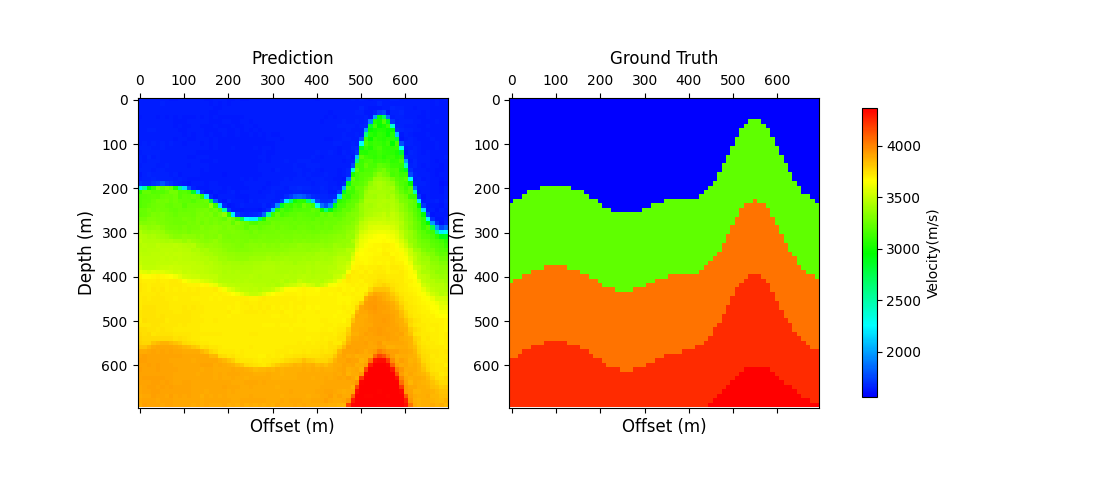

In [ ]:
#@title Evaluación con pesos preentrenados usando norma $\ell_1$
#@markdown Selecciona los parámetros de evaluación.

from IPython.display import Image, display
import subprocess
import os
import re

# ============================================================
# PARÁMETROS DE EVALUACIÓN
# ============================================================

Dataset = "curvevel-a" #@param {type:"string"}

Carpeta = "curvevel_L1" #@param {type:"string"}

Nombre_de_la_red = "InversionNet" #@param {type:"string"}

Conjunto_de_prueba = "Curve_val.txt" #@param {type:"string"}

Archivo_pth = "cva_l1.pth" #@param {type:"string"}


# ============================================================
# VISUALIZACIÓN
# ============================================================

Visualizar = True #@param {type:"boolean"}

Batches_visualizar = 1 #@param {type:"integer"}

Muestras_por_batch = 1 #@param {type:"integer"}

Indice_global = 0 #@param {type:"integer"}

# Permite mostrar toda la salida de predict.py si se desea
Mostrar_salida_completa = False #@param {type:"boolean"}


# ============================================================
# CHECKPOINT
# ============================================================

Checkpoint = os.path.join(
    PRETRAINED_ROOT,
    Archivo_pth
)

flag_visualizar = "--vis" if Visualizar else ""


# ============================================================
# CONSTRUCCIÓN DEL COMANDO
# ============================================================

cmd = (
    f'python predict.py '
    f'-ds "{Dataset}" '
    f'-o "{OUTPUT_ROOT}" '
    f'-n "{Carpeta}" '
    f'-m "{Nombre_de_la_red}" '
    f'-v "{Conjunto_de_prueba}" '
    f'-r "{Checkpoint}" '
    f'{flag_visualizar} '
    f'-vb {Batches_visualizar} '
    f'-vsa {Muestras_por_batch} '
    f'-j 2 '
    f'--global-sample-idx {Indice_global}'
)


# ============================================================
# EJECUCIÓN
# ============================================================

print("========== EJECUTANDO INVERSIÓN ==========")

print(f"Dataset:    {Dataset}")
print(f"Red:        {Nombre_de_la_red}")
print(f"Checkpoint: {Archivo_pth}")
print(f"Muestra:    {Indice_global}")


resultado = subprocess.run(
    cmd,
    shell=True,
    capture_output=True,
    text=True
)


# ============================================================
# RESULTADO DE LA EJECUCIÓN
# ============================================================

if resultado.returncode == 0:

    print("\n✅ Inferencia finalizada correctamente.")

else:

    print("\n❌ Ocurrió un error durante la inferencia.")

    print(resultado.stderr)


# ============================================================
# CAPTURAR SALIDA DE predict.py
# ============================================================

salida = resultado.stdout


# ============================================================
# FUNCIÓN PARA EXTRAER SECCIONES DE LA SALIDA
# ============================================================

def extraer_seccion(texto, nombre):

    patron = (
        r"=+\s*"
        + re.escape(nombre)
        + r"\s*=+\s*\n"
        + r"(.*?)(?=\n\s*=+|\Z)"
    )

    resultado_seccion = re.search(
        patron,
        texto,
        flags=re.DOTALL
    )

    if resultado_seccion:

        return resultado_seccion.group(1).strip()

    return None


# ============================================================
# MÉTRICAS NORMALIZADAS [0,1]
# ============================================================

metricas_comparables = extraer_seccion(
    salida,
    "COMPARABLE NORMALIZED METRICS [0,1]"
)

if metricas_comparables:

    print(
        "\n========== MÉTRICAS NORMALIZADAS [0,1] =========="
    )

    print(metricas_comparables)


# ============================================================
# SALIDA COMPLETA OPCIONAL
# ============================================================

if Mostrar_salida_completa:

    print(
        "\n========== SALIDA COMPLETA DE predict.py =========="
    )

    print(salida)


# ============================================================
# VISUALIZACIÓN DEL RESULTADO
# ============================================================

ruta_imagen = os.path.join(
    OUTPUT_ROOT,
    Carpeta,
    "visualization",
    "V_0_0.png"
)


if os.path.exists(ruta_imagen):

    print(
        "\n========== RESULTADO =========="
    )

    imagen = Image(
        ruta_imagen,
        width=600,
        height=300
    )

    display(imagen)

else:

    print(
        "\n⚠️ No se encontró la imagen en:",
        ruta_imagen
    )

========== EJECUTANDO INVERSIÓN ==========
Dataset:    curvevel-a
Red:        InversionNet
Checkpoint: cva_l2.pth
Muestra:    0

✅ Inferencia finalizada correctamente.

========== MÉTRICAS NORMALIZADAS [0,1] ==========
Comparable MAE [0,1]: 0.060927
Comparable MSE [0,1]: 0.008621
Comparable SSIM [0,1]: 0.745781
Comparable PSNR [0,1]: 20.644197

========== MÉTRICAS EN UNIDADES FÍSICAS ==========
* Velocity MAE: 182.7811737060547
 * Velocity MSE: 77592.984375
Testing time 0:00:01

========== RESULTADO ==========


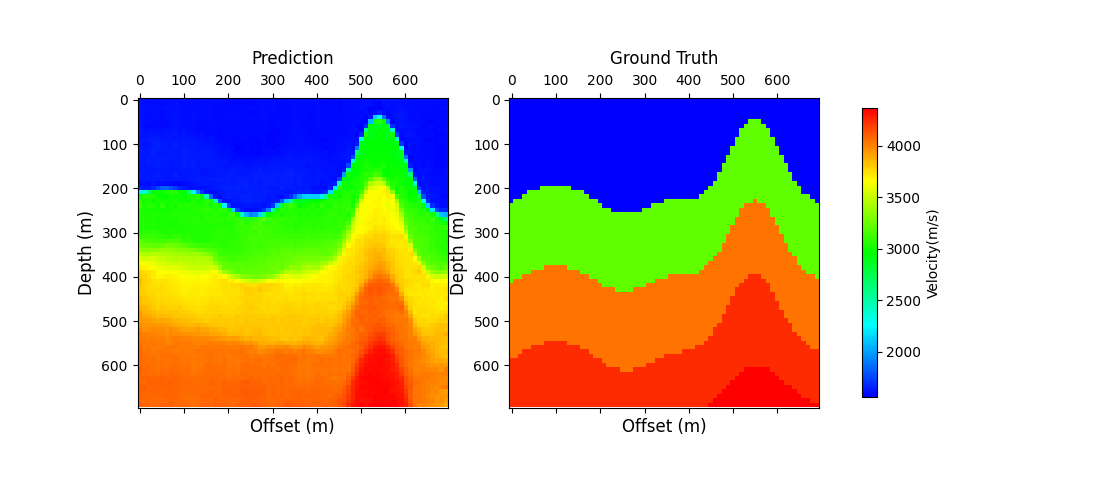

In [ ]:
#@title Evaluación con pesos preentrenados usando norma $\ell_2$
#@markdown Selecciona los parámetros de evaluación.

from IPython.display import Image, display
import subprocess
import os
import re

# ============================================================
# PARÁMETROS DE EVALUACIÓN
# ============================================================

Dataset = "curvevel-a" #@param {type:"string"}
Carpeta = "curvevel_L2" #@param {type:"string"}
Nombre_de_la_red = "InversionNet" #@param {type:"string"}
Conjunto_de_prueba = "Curve_val.txt" #@param {type:"string"}
Archivo_pth = "cva_l2.pth" #@param {type:"string"}


# ============================================================
# VISUALIZACIÓN
# ============================================================

Visualizar = True #@param {type:"boolean"}
Batches_visualizar = 1 #@param {type:"integer"}
Muestras_por_batch = 1 #@param {type:"integer"}
Indice_global = 0 #@param {type:"integer"}

# Mostrar toda la salida de predict.py
Mostrar_salida_completa = False #@param {type:"boolean"}


# ============================================================
# CHECKPOINT
# ============================================================

Checkpoint = os.path.join(
    PRETRAINED_ROOT,
    Archivo_pth
)

flag_visualizar = "--vis" if Visualizar else ""


# ============================================================
# CONSTRUCCIÓN DEL COMANDO
# ============================================================

cmd = (
    f'python predict.py '
    f'-ds "{Dataset}" '
    f'-o "{OUTPUT_ROOT}" '
    f'-n "{Carpeta}" '
    f'-m "{Nombre_de_la_red}" '
    f'-v "{Conjunto_de_prueba}" '
    f'-r "{Checkpoint}" '
    f'{flag_visualizar} '
    f'-vb {Batches_visualizar} '
    f'-vsa {Muestras_por_batch} '
    f'-j 2 '
    f'--global-sample-idx {Indice_global}'
)


# ============================================================
# EJECUCIÓN
# ============================================================

print("========== EJECUTANDO INVERSIÓN ==========")

print(f"Dataset:    {Dataset}")
print(f"Red:        {Nombre_de_la_red}")
print(f"Checkpoint: {Archivo_pth}")
print(f"Muestra:    {Indice_global}")

resultado = subprocess.run(
    cmd,
    shell=True,
    capture_output=True,
    text=True
)


# ============================================================
# RESULTADO DE LA EJECUCIÓN
# ============================================================

if resultado.returncode == 0:

    print("\n✅ Inferencia finalizada correctamente.")

else:

    print("\n❌ Ocurrió un error durante la inferencia.")
    print(resultado.stderr)


# ============================================================
# MOSTRAR MÉTRICAS
# ============================================================

salida = resultado.stdout


def extraer_seccion(texto, nombre):

    patron = (
        r"=+\s*"
        + re.escape(nombre)
        + r"\s*=+\s*\n"
        + r"(.*?)(?=\n\s*=+|\Z)"
    )

    resultado_seccion = re.search(
        patron,
        texto,
        flags=re.DOTALL
    )

    if resultado_seccion:
        return resultado_seccion.group(1).strip()

    return None


# ------------------------------------------------------------
# MÉTRICAS NORMALIZADAS [0,1]
# ------------------------------------------------------------

metricas_comparables = extraer_seccion(
    salida,
    "COMPARABLE NORMALIZED METRICS [0,1]"
)

if metricas_comparables:

    print("\n========== MÉTRICAS NORMALIZADAS [0,1] ==========")
    print(metricas_comparables)


# ------------------------------------------------------------
# MÉTRICAS EN VELOCIDAD FÍSICA
# ------------------------------------------------------------

metricas_fisicas = extraer_seccion(
    salida,
    "PHYSICAL VELOCITY METRICS"
)

if metricas_fisicas:

    print("\n========== MÉTRICAS EN UNIDADES FÍSICAS ==========")
    print(metricas_fisicas)


# ============================================================
# SALIDA COMPLETA OPCIONAL
# ============================================================

if Mostrar_salida_completa:

    print("\n========== SALIDA COMPLETA ==========")
    print(salida)


# ============================================================
# VISUALIZACIÓN DEL RESULTADO
# ============================================================

ruta_imagen = os.path.join(
    OUTPUT_ROOT,
    Carpeta,
    "visualization",
    "V_0_0.png"
)

if os.path.exists(ruta_imagen):

    print("\n========== RESULTADO ==========")

    imagen = Image(
        ruta_imagen,
        width=600,
        height=300
    )

    display(imagen)

else:

    print(
        "\n⚠️ No se encontró la imagen en:",
        ruta_imagen
    )

### 4.2 Familia **FlatFault_A**

Esta familia contiene modelos con **fallas planas**. De nuevo se muestran dos configuraciones de InversionNet, según el tipo de función de pérdida usada durante el entrenamiento.


========== EJECUTANDO INVERSIÓN ==========
Dataset:    flatfault-a
Red:        InversionNet
Checkpoint: ffa_l1.pth
Muestra:    0

✅ Inferencia finalizada correctamente.

========== MÉTRICAS NORMALIZADAS [0,1] ==========
Comparable MAE [0,1]: 0.064644
Comparable MSE [0,1]: 0.006386
Comparable SSIM [0,1]: 0.899602
Comparable PSNR [0,1]: 21.947586

========== MÉTRICAS EN UNIDADES FÍSICAS ==========
* Velocity MAE: 193.93190002441406
 * Velocity MSE: 57475.53125
Testing time 0:00:01

========== RESULTADO ==========


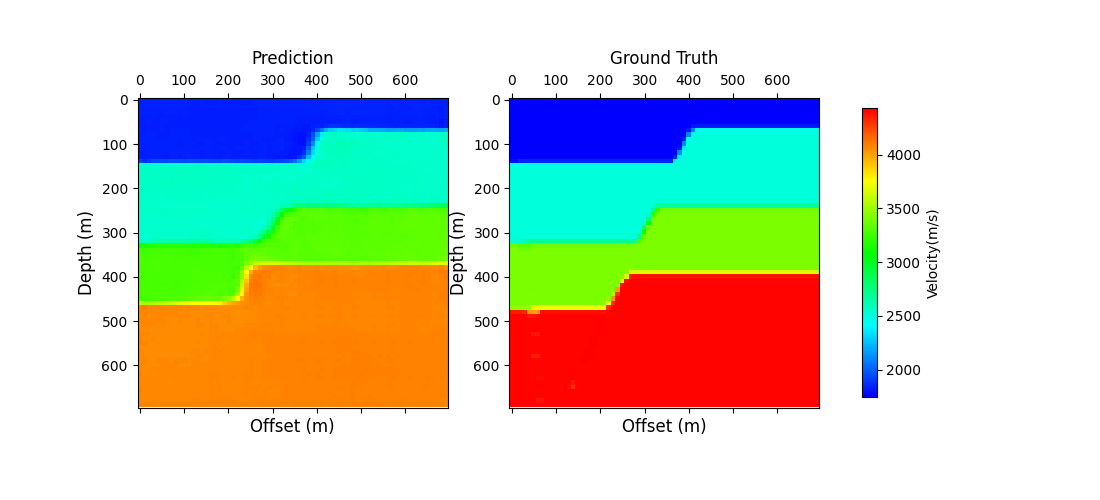

In [ ]:
#@title Evaluación con pesos preentrenados usando norma $\ell_1$
#@markdown Selecciona los parámetros de evaluación.

from IPython.display import Image, display
import subprocess
import os
import re

# ============================================================
# PARÁMETROS DE EVALUACIÓN
# ============================================================

Dataset = "flatfault-a" #@param {type:"string"}

Carpeta = "flatfault_L1" #@param {type:"string"}

Nombre_de_la_red = "InversionNet" #@param {type:"string"}

Conjunto_de_prueba = "FlatFault_val.txt" #@param {type:"string"}

Archivo_pth = "ffa_l1.pth" #@param {type:"string"}


# ============================================================
# VISUALIZACIÓN
# ============================================================

Visualizar = True #@param {type:"boolean"}

Batches_visualizar = 1 #@param {type:"integer"}

Muestras_por_batch = 1 #@param {type:"integer"}

Indice_global = 0 #@param {type:"integer"}

# Permite mostrar toda la salida de predict.py si se desea
Mostrar_salida_completa = False #@param {type:"boolean"}


# ============================================================
# CHECKPOINT
# ============================================================

Checkpoint = os.path.join(
    PRETRAINED_ROOT,
    Archivo_pth
)

flag_visualizar = "--vis" if Visualizar else ""


# ============================================================
# CONSTRUCCIÓN DEL COMANDO
# ============================================================

cmd = (
    f'python predict.py '
    f'-ds "{Dataset}" '
    f'-o "{OUTPUT_ROOT}" '
    f'-n "{Carpeta}" '
    f'-m "{Nombre_de_la_red}" '
    f'-v "{Conjunto_de_prueba}" '
    f'-r "{Checkpoint}" '
    f'{flag_visualizar} '
    f'-vb {Batches_visualizar} '
    f'-vsa {Muestras_por_batch} '
    f'-j 2 '
    f'--global-sample-idx {Indice_global}'
)


# ============================================================
# EJECUCIÓN
# ============================================================

print("========== EJECUTANDO INVERSIÓN ==========")

print(f"Dataset:    {Dataset}")
print(f"Red:        {Nombre_de_la_red}")
print(f"Checkpoint: {Archivo_pth}")
print(f"Muestra:    {Indice_global}")


resultado = subprocess.run(
    cmd,
    shell=True,
    capture_output=True,
    text=True
)


# ============================================================
# RESULTADO DE LA EJECUCIÓN
# ============================================================

if resultado.returncode == 0:

    print("\n✅ Inferencia finalizada correctamente.")

else:

    print("\n❌ Ocurrió un error durante la inferencia.")
    print(resultado.stderr)


# ============================================================
# CAPTURAR SALIDA DE predict.py
# ============================================================

salida = resultado.stdout


# ============================================================
# FUNCIÓN PARA EXTRAER SECCIONES DE LA SALIDA
# ============================================================

def extraer_seccion(texto, nombre):

    patron = (
        r"=+\s*"
        + re.escape(nombre)
        + r"\s*=+\s*\n"
        + r"(.*?)(?=\n\s*=+|\Z)"
    )

    resultado_seccion = re.search(
        patron,
        texto,
        flags=re.DOTALL
    )

    if resultado_seccion:
        return resultado_seccion.group(1).strip()

    return None


# ============================================================
# MÉTRICAS NORMALIZADAS [0,1]
# ============================================================

metricas_comparables = extraer_seccion(
    salida,
    "COMPARABLE NORMALIZED METRICS [0,1]"
)

if metricas_comparables:

    print(
        "\n========== MÉTRICAS NORMALIZADAS [0,1] =========="
    )

    print(metricas_comparables)


# ============================================================
# MÉTRICAS EN VELOCIDAD FÍSICA
# ============================================================

metricas_fisicas = extraer_seccion(
    salida,
    "PHYSICAL VELOCITY METRICS"
)

if metricas_fisicas:

    print(
        "\n========== MÉTRICAS EN UNIDADES FÍSICAS =========="
    )

    print(metricas_fisicas)


# ============================================================
# SALIDA COMPLETA OPCIONAL
# ============================================================

if Mostrar_salida_completa:

    print(
        "\n========== SALIDA COMPLETA DE predict.py =========="
    )

    print(salida)


# ============================================================
# VISUALIZACIÓN DEL RESULTADO
# ============================================================

ruta_imagen = os.path.join(
    OUTPUT_ROOT,
    Carpeta,
    "visualization",
    "V_0_0.png"
)


if os.path.exists(ruta_imagen):

    print(
        "\n========== RESULTADO =========="
    )

    imagen = Image(
        ruta_imagen,
        width=600,
        height=300
    )

    display(imagen)

else:

    print(
        "\n⚠️ No se encontró la imagen en:",
        ruta_imagen
    )

========== EJECUTANDO INVERSIÓN ==========
Dataset:    flatfault-a
Red:        InversionNet
Checkpoint: ffa_l2.pth
Muestra:    0

✅ Inferencia finalizada correctamente.

========== MÉTRICAS NORMALIZADAS [0,1] ==========
Comparable MAE [0,1]: 0.042719
Comparable MSE [0,1]: 0.002849
Comparable SSIM [0,1]: 0.910531
Comparable PSNR [0,1]: 25.453270

========== MÉTRICAS EN UNIDADES FÍSICAS ==========
* Velocity MAE: 128.1569061279297
 * Velocity MSE: 25639.76171875
Testing time 0:00:03

========== RESULTADO ==========


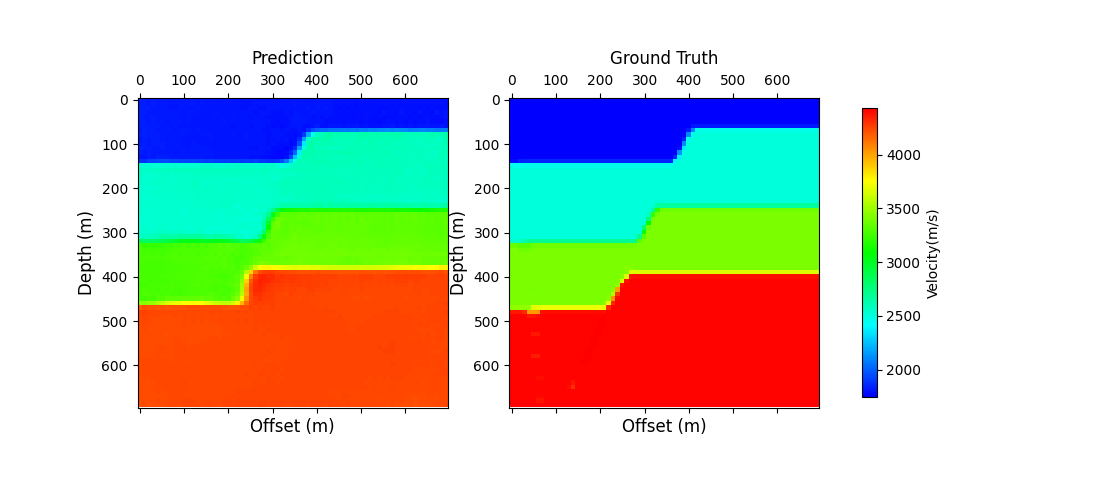

In [ ]:
#@title Evaluación con pesos preentrenados usando norma $\ell_2$
#@markdown Selecciona los parámetros de evaluación.

from IPython.display import Image, display
import subprocess
import os
import re

# ============================================================
# PARÁMETROS DE EVALUACIÓN
# ============================================================

Dataset = "flatfault-a" #@param {type:"string"}

Carpeta = "flatfault_L2" #@param {type:"string"}

Nombre_de_la_red = "InversionNet" #@param {type:"string"}

Conjunto_de_prueba = "FlatFault_val.txt" #@param {type:"string"}

Archivo_pth = "ffa_l2.pth" #@param {type:"string"}


# ============================================================
# VISUALIZACIÓN
# ============================================================

Visualizar = True #@param {type:"boolean"}

Batches_visualizar = 1 #@param {type:"integer"}

Muestras_por_batch = 1 #@param {type:"integer"}

Indice_global = 0 #@param {type:"integer"}

# Permite mostrar toda la salida de predict.py si se desea
Mostrar_salida_completa = False #@param {type:"boolean"}


# ============================================================
# CHECKPOINT
# ============================================================

Checkpoint = os.path.join(
    PRETRAINED_ROOT,
    Archivo_pth
)

flag_visualizar = "--vis" if Visualizar else ""


# ============================================================
# CONSTRUCCIÓN DEL COMANDO
# ============================================================

cmd = (
    f'python predict.py '
    f'-ds "{Dataset}" '
    f'-o "{OUTPUT_ROOT}" '
    f'-n "{Carpeta}" '
    f'-m "{Nombre_de_la_red}" '
    f'-v "{Conjunto_de_prueba}" '
    f'-r "{Checkpoint}" '
    f'{flag_visualizar} '
    f'-vb {Batches_visualizar} '
    f'-vsa {Muestras_por_batch} '
    f'-j 2 '
    f'--global-sample-idx {Indice_global}'
)


# ============================================================
# EJECUCIÓN
# ============================================================

print("========== EJECUTANDO INVERSIÓN ==========")

print(f"Dataset:    {Dataset}")
print(f"Red:        {Nombre_de_la_red}")
print(f"Checkpoint: {Archivo_pth}")
print(f"Muestra:    {Indice_global}")


resultado = subprocess.run(
    cmd,
    shell=True,
    capture_output=True,
    text=True
)


# ============================================================
# RESULTADO DE LA EJECUCIÓN
# ============================================================

if resultado.returncode == 0:

    print("\n✅ Inferencia finalizada correctamente.")

else:

    print("\n❌ Ocurrió un error durante la inferencia.")
    print(resultado.stderr)


# ============================================================
# CAPTURAR SALIDA DE predict.py
# ============================================================

salida = resultado.stdout


# ============================================================
# FUNCIÓN PARA EXTRAER SECCIONES DE LA SALIDA
# ============================================================

def extraer_seccion(texto, nombre):

    patron = (
        r"=+\s*"
        + re.escape(nombre)
        + r"\s*=+\s*\n"
        + r"(.*?)(?=\n\s*=+|\Z)"
    )

    resultado_seccion = re.search(
        patron,
        texto,
        flags=re.DOTALL
    )

    if resultado_seccion:
        return resultado_seccion.group(1).strip()

    return None


# ============================================================
# MÉTRICAS NORMALIZADAS [0,1]
# ============================================================

metricas_comparables = extraer_seccion(
    salida,
    "COMPARABLE NORMALIZED METRICS [0,1]"
)

if metricas_comparables:

    print(
        "\n========== MÉTRICAS NORMALIZADAS [0,1] =========="
    )

    print(metricas_comparables)


# ============================================================
# MÉTRICAS EN VELOCIDAD FÍSICA
# ============================================================

metricas_fisicas = extraer_seccion(
    salida,
    "PHYSICAL VELOCITY METRICS"
)

if metricas_fisicas:

    print(
        "\n========== MÉTRICAS EN UNIDADES FÍSICAS =========="
    )

    print(metricas_fisicas)


# ============================================================
# SALIDA COMPLETA OPCIONAL
# ============================================================

if Mostrar_salida_completa:

    print(
        "\n========== SALIDA COMPLETA DE predict.py =========="
    )

    print(salida)


# ============================================================
# VISUALIZACIÓN DEL RESULTADO
# ============================================================

ruta_imagen = os.path.join(
    OUTPUT_ROOT,
    Carpeta,
    "visualization",
    "V_0_0.png"
)


if os.path.exists(ruta_imagen):

    print(
        "\n========== RESULTADO =========="
    )

    imagen = Image(
        ruta_imagen,
        width=600,
        height=300
    )

    display(imagen)

else:

    print(
        "\n⚠️ No se encontró la imagen en:",
        ruta_imagen
    )

---

## 5. Evaluación con VelocityGAN

En esta sección se utiliza la arquitectura **VelocityGAN** ([Zhang and Lin, 2019](https://arxiv.org/abs/1809.10262)).

La estructura de la red puede consultarse en el archivo correspondiente donde se encuentra definida la arquitectura de **VelocityGAN**.

Las siguientes subsecciones utilizan los pesos preentrenados de **VelocityGAN** para estimar el modelo de velocidad a partir de los registros sísmicos de entrada.

Para cada familia se consideran las variantes disponibles del modelo preentrenado, diferenciadas por la función de pérdida utilizada durante el entrenamiento.

### Norma $\ell_1$ — MAE

La pérdida $\ell_1$ mide la diferencia absoluta entre el modelo de velocidad predicho por la red y el modelo verdadero:

$$
\left\|
g_{\theta}(d_i)-c_i
\right\|_1
$$

Esta función corresponde al **error absoluto medio (MAE)**.

### Norma $\ell_2$ — MSE

La pérdida $\ell_2$ utiliza el cuadrado de la diferencia entre la predicción y el modelo verdadero:

$$
\left\|
g_{\theta}(d_i)-c_i
\right\|_2^2
$$

Esta función corresponde al **error cuadrático medio (MSE)**.

donde:

- $d_i$ representa los datos sísmicos de entrada de la muestra $i$,
- $c_i$ representa el modelo de velocidad verdadero,
- $g_{\theta}$ representa VelocityGAN con parámetros entrenables $\theta$.

### 5.1 Familia **CurveVel_A**

Esta familia contiene modelos con **estructuras geológicas curvas**. A continuación se presentan dos evaluaciones con VelocityGAN: una utilizando pesos entrenados con pérdida **$\ell_1$** y otra con pérdida **$\ell_2$**.


========== EJECUTANDO INVERSIÓN ==========
Dataset:    curvevel-a
Red:        InversionNet
Checkpoint: curvevel_a_l1_480.pth
Muestra:    0

✅ Inferencia finalizada correctamente.

========== MÉTRICAS NORMALIZADAS [0,1] ==========
Comparable MAE [0,1]: 0.086545
Comparable MSE [0,1]: 0.011381
Comparable SSIM [0,1]: 0.773179
Comparable PSNR [0,1]: 19.438036

========== RESULTADO ==========


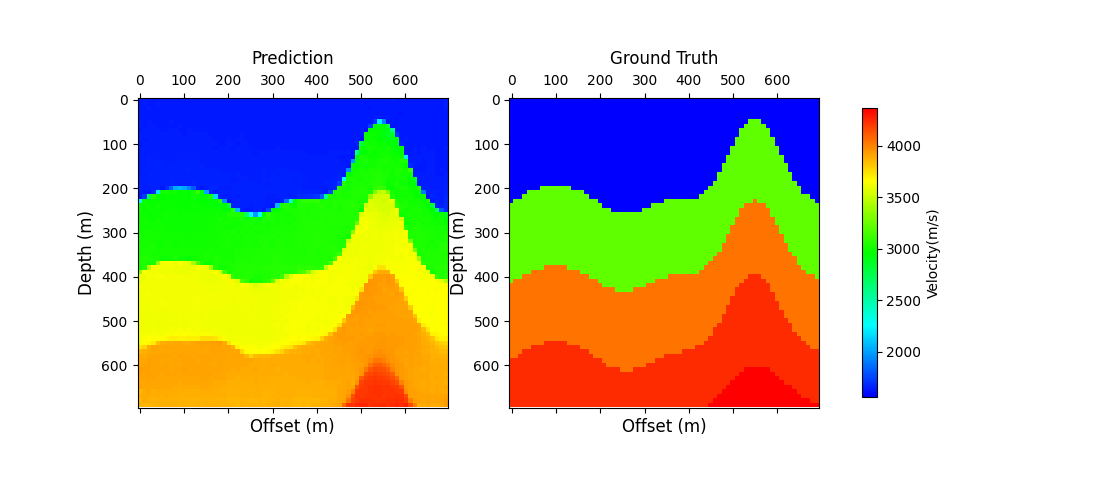

In [ ]:
#@title Evaluación con pesos preentrenados usando norma $\ell_1$
#@markdown Selecciona los parámetros de evaluación.

from IPython.display import Image, display
import subprocess
import os
import re

# ============================================================
# PARÁMETROS DE EVALUACIÓN
# ============================================================

Dataset = "curvevel-a" #@param {type:"string"}

Carpeta = "curvevel_L1" #@param {type:"string"}

Nombre_de_la_red = "InversionNet" #@param {type:"string"}

Conjunto_de_prueba = "Curve_val.txt" #@param {type:"string"}

Archivo_pth = "curvevel_a_l1_480.pth" #@param {type:"string"}


# ============================================================
# VISUALIZACIÓN
# ============================================================

Visualizar = True #@param {type:"boolean"}

Batches_visualizar = 1 #@param {type:"integer"}

Muestras_por_batch = 1 #@param {type:"integer"}

Indice_global = 0 #@param {type:"integer"}

# Permite mostrar toda la salida de predict.py si se desea
Mostrar_salida_completa = False #@param {type:"boolean"}


# ============================================================
# CHECKPOINT
# ============================================================

Checkpoint = os.path.join(
    PRETRAINED_ROOT,
    Archivo_pth
)

flag_visualizar = "--vis" if Visualizar else ""


# ============================================================
# CONSTRUCCIÓN DEL COMANDO
# ============================================================

cmd = (
    f'python predict.py '
    f'-ds "{Dataset}" '
    f'-o "{OUTPUT_ROOT}" '
    f'-n "{Carpeta}" '
    f'-m "{Nombre_de_la_red}" '
    f'-v "{Conjunto_de_prueba}" '
    f'-r "{Checkpoint}" '
    f'{flag_visualizar} '
    f'-vb {Batches_visualizar} '
    f'-vsa {Muestras_por_batch} '
    f'-j 2 '
    f'--global-sample-idx {Indice_global}'
)


# ============================================================
# EJECUCIÓN
# ============================================================

print("========== EJECUTANDO INVERSIÓN ==========")

print(f"Dataset:    {Dataset}")
print(f"Red:        {Nombre_de_la_red}")
print(f"Checkpoint: {Archivo_pth}")
print(f"Muestra:    {Indice_global}")


resultado = subprocess.run(
    cmd,
    shell=True,
    capture_output=True,
    text=True
)


# ============================================================
# RESULTADO DE LA EJECUCIÓN
# ============================================================

if resultado.returncode == 0:

    print("\n✅ Inferencia finalizada correctamente.")

else:

    print("\n❌ Ocurrió un error durante la inferencia.")

    print(resultado.stderr)


# ============================================================
# CAPTURAR SALIDA DE predict.py
# ============================================================

salida = resultado.stdout


# ============================================================
# FUNCIÓN PARA EXTRAER SECCIONES DE LA SALIDA
# ============================================================

def extraer_seccion(texto, nombre):

    patron = (
        r"=+\s*"
        + re.escape(nombre)
        + r"\s*=+\s*\n"
        + r"(.*?)(?=\n\s*=+|\Z)"
    )

    resultado_seccion = re.search(
        patron,
        texto,
        flags=re.DOTALL
    )

    if resultado_seccion:

        return resultado_seccion.group(1).strip()

    return None


# ============================================================
# MÉTRICAS NORMALIZADAS [0,1]
# ============================================================

metricas_comparables = extraer_seccion(
    salida,
    "COMPARABLE NORMALIZED METRICS [0,1]"
)

if metricas_comparables:

    print(
        "\n========== MÉTRICAS NORMALIZADAS [0,1] =========="
    )

    print(metricas_comparables)


# ============================================================
# SALIDA COMPLETA OPCIONAL
# ============================================================

if Mostrar_salida_completa:

    print(
        "\n========== SALIDA COMPLETA DE predict.py =========="
    )

    print(salida)


# ============================================================
# VISUALIZACIÓN DEL RESULTADO
# ============================================================

ruta_imagen = os.path.join(
    OUTPUT_ROOT,
    Carpeta,
    "visualization",
    "V_0_0.png"
)


if os.path.exists(ruta_imagen):

    print(
        "\n========== RESULTADO =========="
    )

    imagen = Image(
        ruta_imagen,
        width=600,
        height=300
    )

    display(imagen)

else:

    print(
        "\n⚠️ No se encontró la imagen en:",
        ruta_imagen
    )

========== EJECUTANDO INVERSIÓN ==========
Dataset:    curvevel-a
Red:        InversionNet
Checkpoint: curvevel_a_l2_480.pth
Muestra:    0

✅ Inferencia finalizada correctamente.

========== MÉTRICAS NORMALIZADAS [0,1] ==========
Comparable MAE [0,1]: 0.056998
Comparable MSE [0,1]: 0.007538
Comparable SSIM [0,1]: 0.776412
Comparable PSNR [0,1]: 21.227707

========== RESULTADO ==========


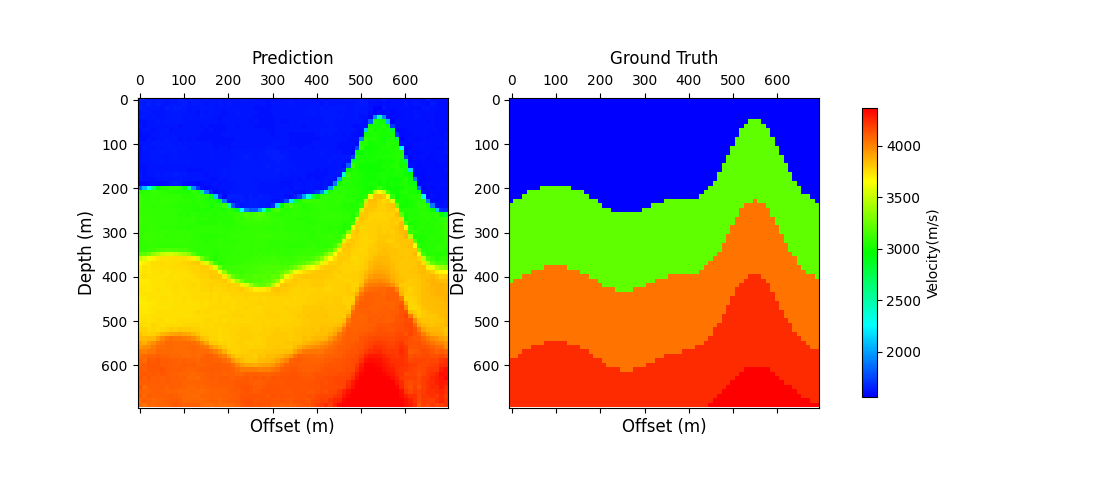

In [ ]:
#@title Evaluación con pesos preentrenados usando norma $\ell_2$
#@markdown Selecciona los parámetros de evaluación.

from IPython.display import Image, display
import subprocess
import os
import re

# ============================================================
# PARÁMETROS DE EVALUACIÓN
# ============================================================

Dataset = "curvevel-a" #@param {type:"string"}

Carpeta = "curvevel_L1" #@param {type:"string"}

Nombre_de_la_red = "InversionNet" #@param {type:"string"}

Conjunto_de_prueba = "Curve_val.txt" #@param {type:"string"}

Archivo_pth = "curvevel_a_l2_480.pth" #@param {type:"string"}


# ============================================================
# VISUALIZACIÓN
# ============================================================

Visualizar = True #@param {type:"boolean"}

Batches_visualizar = 1 #@param {type:"integer"}

Muestras_por_batch = 1 #@param {type:"integer"}

Indice_global = 0 #@param {type:"integer"}

# Permite mostrar toda la salida de predict.py si se desea
Mostrar_salida_completa = False #@param {type:"boolean"}


# ============================================================
# CHECKPOINT
# ============================================================

Checkpoint = os.path.join(
    PRETRAINED_ROOT,
    Archivo_pth
)

flag_visualizar = "--vis" if Visualizar else ""


# ============================================================
# CONSTRUCCIÓN DEL COMANDO
# ============================================================

cmd = (
    f'python predict.py '
    f'-ds "{Dataset}" '
    f'-o "{OUTPUT_ROOT}" '
    f'-n "{Carpeta}" '
    f'-m "{Nombre_de_la_red}" '
    f'-v "{Conjunto_de_prueba}" '
    f'-r "{Checkpoint}" '
    f'{flag_visualizar} '
    f'-vb {Batches_visualizar} '
    f'-vsa {Muestras_por_batch} '
    f'-j 2 '
    f'--global-sample-idx {Indice_global}'
)


# ============================================================
# EJECUCIÓN
# ============================================================

print("========== EJECUTANDO INVERSIÓN ==========")

print(f"Dataset:    {Dataset}")
print(f"Red:        {Nombre_de_la_red}")
print(f"Checkpoint: {Archivo_pth}")
print(f"Muestra:    {Indice_global}")


resultado = subprocess.run(
    cmd,
    shell=True,
    capture_output=True,
    text=True
)


# ============================================================
# RESULTADO DE LA EJECUCIÓN
# ============================================================

if resultado.returncode == 0:

    print("\n✅ Inferencia finalizada correctamente.")

else:

    print("\n❌ Ocurrió un error durante la inferencia.")

    print(resultado.stderr)


# ============================================================
# CAPTURAR SALIDA DE predict.py
# ============================================================

salida = resultado.stdout


# ============================================================
# FUNCIÓN PARA EXTRAER SECCIONES DE LA SALIDA
# ============================================================

def extraer_seccion(texto, nombre):

    patron = (
        r"=+\s*"
        + re.escape(nombre)
        + r"\s*=+\s*\n"
        + r"(.*?)(?=\n\s*=+|\Z)"
    )

    resultado_seccion = re.search(
        patron,
        texto,
        flags=re.DOTALL
    )

    if resultado_seccion:

        return resultado_seccion.group(1).strip()

    return None


# ============================================================
# MÉTRICAS NORMALIZADAS [0,1]
# ============================================================

metricas_comparables = extraer_seccion(
    salida,
    "COMPARABLE NORMALIZED METRICS [0,1]"
)

if metricas_comparables:

    print(
        "\n========== MÉTRICAS NORMALIZADAS [0,1] =========="
    )

    print(metricas_comparables)


# ============================================================
# SALIDA COMPLETA OPCIONAL
# ============================================================

if Mostrar_salida_completa:

    print(
        "\n========== SALIDA COMPLETA DE predict.py =========="
    )

    print(salida)


# ============================================================
# VISUALIZACIÓN DEL RESULTADO
# ============================================================

ruta_imagen = os.path.join(
    OUTPUT_ROOT,
    Carpeta,
    "visualization",
    "V_0_0.png"
)


if os.path.exists(ruta_imagen):

    print(
        "\n========== RESULTADO =========="
    )

    imagen = Image(
        ruta_imagen,
        width=600,
        height=300
    )

    display(imagen)

else:

    print(
        "\n⚠️ No se encontró la imagen en:",
        ruta_imagen
    )

### 5.2 Familia **FlatFault_A**

Esta familia contiene modelos con **fallas planas**. De nuevo se muestran dos configuraciones de VelocityGAN, según el tipo de función de pérdida usada durante el entrenamiento.

========== EJECUTANDO INVERSIÓN ==========
Dataset:    flatfault-a
Red:        InversionNet
Checkpoint: flatfault_a_l1_480.pth
Muestra:    0

✅ Inferencia finalizada correctamente.

========== MÉTRICAS NORMALIZADAS [0,1] ==========
Comparable MAE [0,1]: 0.025701
Comparable MSE [0,1]: 0.001411
Comparable SSIM [0,1]: 0.945556
Comparable PSNR [0,1]: 28.503422

========== MÉTRICAS EN UNIDADES FÍSICAS ==========
* Velocity MAE: 77.10313415527344
 * Velocity MSE: 12702.7373046875
Testing time 0:00:02

========== RESULTADO ==========


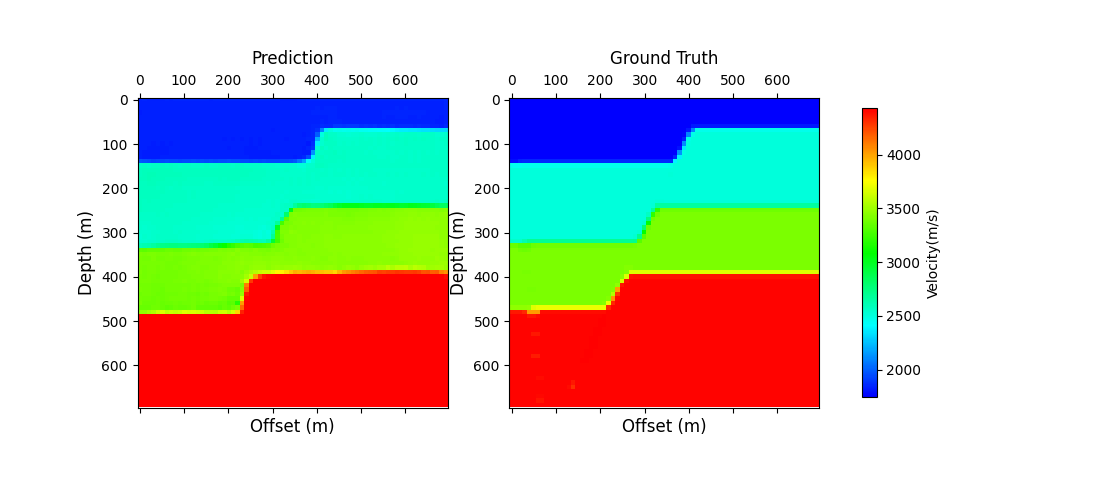

In [ ]:
#@title Evaluación con pesos preentrenados usando norma $\ell_1$
#@markdown Selecciona los parámetros de evaluación.

from IPython.display import Image, display
import subprocess
import os
import re

# ============================================================
# PARÁMETROS DE EVALUACIÓN
# ============================================================

Dataset = "flatfault-a" #@param {type:"string"}

Carpeta = "flatfault_L1" #@param {type:"string"}

Nombre_de_la_red = "InversionNet" #@param {type:"string"}

Conjunto_de_prueba = "FlatFault_val.txt" #@param {type:"string"}

Archivo_pth = "flatfault_a_l1_480.pth" #@param {type:"string"}


# ============================================================
# VISUALIZACIÓN
# ============================================================

Visualizar = True #@param {type:"boolean"}

Batches_visualizar = 1 #@param {type:"integer"}

Muestras_por_batch = 1 #@param {type:"integer"}

Indice_global = 0 #@param {type:"integer"}

# Permite mostrar toda la salida de predict.py si se desea
Mostrar_salida_completa = False #@param {type:"boolean"}


# ============================================================
# CHECKPOINT
# ============================================================

Checkpoint = os.path.join(
    PRETRAINED_ROOT,
    Archivo_pth
)

flag_visualizar = "--vis" if Visualizar else ""


# ============================================================
# CONSTRUCCIÓN DEL COMANDO
# ============================================================

cmd = (
    f'python predict.py '
    f'-ds "{Dataset}" '
    f'-o "{OUTPUT_ROOT}" '
    f'-n "{Carpeta}" '
    f'-m "{Nombre_de_la_red}" '
    f'-v "{Conjunto_de_prueba}" '
    f'-r "{Checkpoint}" '
    f'{flag_visualizar} '
    f'-vb {Batches_visualizar} '
    f'-vsa {Muestras_por_batch} '
    f'-j 2 '
    f'--global-sample-idx {Indice_global}'
)


# ============================================================
# EJECUCIÓN
# ============================================================

print("========== EJECUTANDO INVERSIÓN ==========")

print(f"Dataset:    {Dataset}")
print(f"Red:        {Nombre_de_la_red}")
print(f"Checkpoint: {Archivo_pth}")
print(f"Muestra:    {Indice_global}")


resultado = subprocess.run(
    cmd,
    shell=True,
    capture_output=True,
    text=True
)


# ============================================================
# RESULTADO DE LA EJECUCIÓN
# ============================================================

if resultado.returncode == 0:

    print("\n✅ Inferencia finalizada correctamente.")

else:

    print("\n❌ Ocurrió un error durante la inferencia.")
    print(resultado.stderr)


# ============================================================
# CAPTURAR SALIDA DE predict.py
# ============================================================

salida = resultado.stdout


# ============================================================
# FUNCIÓN PARA EXTRAER SECCIONES DE LA SALIDA
# ============================================================

def extraer_seccion(texto, nombre):

    patron = (
        r"=+\s*"
        + re.escape(nombre)
        + r"\s*=+\s*\n"
        + r"(.*?)(?=\n\s*=+|\Z)"
    )

    resultado_seccion = re.search(
        patron,
        texto,
        flags=re.DOTALL
    )

    if resultado_seccion:
        return resultado_seccion.group(1).strip()

    return None


# ============================================================
# MÉTRICAS NORMALIZADAS [0,1]
# ============================================================

metricas_comparables = extraer_seccion(
    salida,
    "COMPARABLE NORMALIZED METRICS [0,1]"
)

if metricas_comparables:

    print(
        "\n========== MÉTRICAS NORMALIZADAS [0,1] =========="
    )

    print(metricas_comparables)


# ============================================================
# MÉTRICAS EN VELOCIDAD FÍSICA
# ============================================================

metricas_fisicas = extraer_seccion(
    salida,
    "PHYSICAL VELOCITY METRICS"
)

if metricas_fisicas:

    print(
        "\n========== MÉTRICAS EN UNIDADES FÍSICAS =========="
    )

    print(metricas_fisicas)


# ============================================================
# SALIDA COMPLETA OPCIONAL
# ============================================================

if Mostrar_salida_completa:

    print(
        "\n========== SALIDA COMPLETA DE predict.py =========="
    )

    print(salida)


# ============================================================
# VISUALIZACIÓN DEL RESULTADO
# ============================================================

ruta_imagen = os.path.join(
    OUTPUT_ROOT,
    Carpeta,
    "visualization",
    "V_0_0.png"
)


if os.path.exists(ruta_imagen):

    print(
        "\n========== RESULTADO =========="
    )

    imagen = Image(
        ruta_imagen,
        width=600,
        height=300
    )

    display(imagen)

else:

    print(
        "\n⚠️ No se encontró la imagen en:",
        ruta_imagen
    )

========== EJECUTANDO INVERSIÓN ==========
Dataset:    flatfault-a
Red:        InversionNet
Checkpoint: flatfault_a_l2_480.pth
Muestra:    0

✅ Inferencia finalizada correctamente.

========== MÉTRICAS NORMALIZADAS [0,1] ==========
Comparable MAE [0,1]: 0.024803
Comparable MSE [0,1]: 0.001930
Comparable SSIM [0,1]: 0.902016
Comparable PSNR [0,1]: 27.144077

========== MÉTRICAS EN UNIDADES FÍSICAS ==========
* Velocity MAE: 74.4079818725586
 * Velocity MSE: 17371.310546875
Testing time 0:00:01

========== RESULTADO ==========


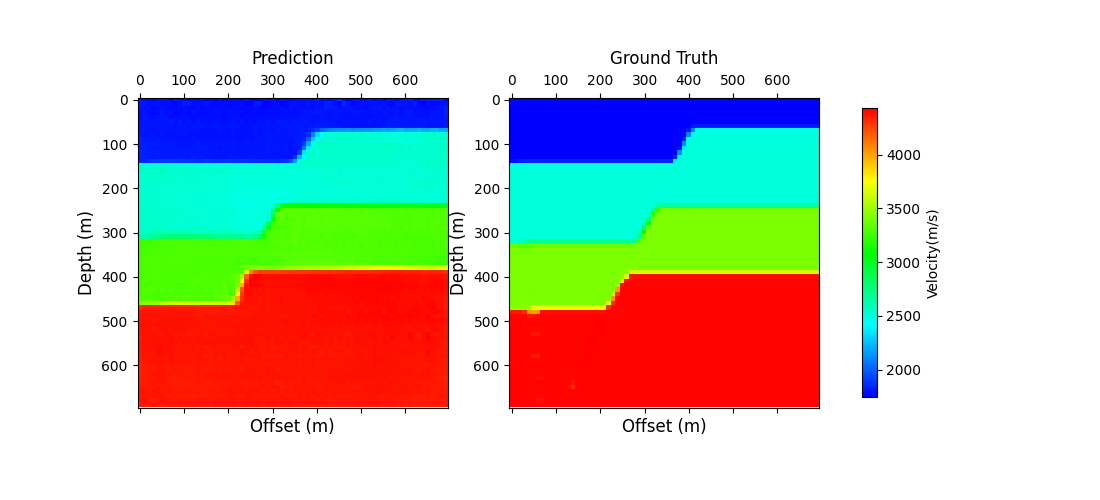

In [ ]:
#@title Evaluación con pesos preentrenados usando norma $\ell_2$
#@markdown Selecciona los parámetros de evaluación.

from IPython.display import Image, display
import subprocess
import os
import re

# ============================================================
# PARÁMETROS DE EVALUACIÓN
# ============================================================

Dataset = "flatfault-a" #@param {type:"string"}

Carpeta = "flatfault_L2" #@param {type:"string"}

Nombre_de_la_red = "InversionNet" #@param {type:"string"}

Conjunto_de_prueba = "FlatFault_val.txt" #@param {type:"string"}

Archivo_pth = "flatfault_a_l2_480.pth" #@param {type:"string"}


# ============================================================
# VISUALIZACIÓN
# ============================================================

Visualizar = True #@param {type:"boolean"}

Batches_visualizar = 1 #@param {type:"integer"}

Muestras_por_batch = 1 #@param {type:"integer"}

Indice_global = 0 #@param {type:"integer"}

# Permite mostrar toda la salida de predict.py si se desea
Mostrar_salida_completa = False #@param {type:"boolean"}


# ============================================================
# CHECKPOINT
# ============================================================

Checkpoint = os.path.join(
    PRETRAINED_ROOT,
    Archivo_pth
)

flag_visualizar = "--vis" if Visualizar else ""


# ============================================================
# CONSTRUCCIÓN DEL COMANDO
# ============================================================

cmd = (
    f'python predict.py '
    f'-ds "{Dataset}" '
    f'-o "{OUTPUT_ROOT}" '
    f'-n "{Carpeta}" '
    f'-m "{Nombre_de_la_red}" '
    f'-v "{Conjunto_de_prueba}" '
    f'-r "{Checkpoint}" '
    f'{flag_visualizar} '
    f'-vb {Batches_visualizar} '
    f'-vsa {Muestras_por_batch} '
    f'-j 2 '
    f'--global-sample-idx {Indice_global}'
)


# ============================================================
# EJECUCIÓN
# ============================================================

print("========== EJECUTANDO INVERSIÓN ==========")

print(f"Dataset:    {Dataset}")
print(f"Red:        {Nombre_de_la_red}")
print(f"Checkpoint: {Archivo_pth}")
print(f"Muestra:    {Indice_global}")


resultado = subprocess.run(
    cmd,
    shell=True,
    capture_output=True,
    text=True
)


# ============================================================
# RESULTADO DE LA EJECUCIÓN
# ============================================================

if resultado.returncode == 0:

    print("\n✅ Inferencia finalizada correctamente.")

else:

    print("\n❌ Ocurrió un error durante la inferencia.")
    print(resultado.stderr)


# ============================================================
# CAPTURAR SALIDA DE predict.py
# ============================================================

salida = resultado.stdout


# ============================================================
# FUNCIÓN PARA EXTRAER SECCIONES DE LA SALIDA
# ============================================================

def extraer_seccion(texto, nombre):

    patron = (
        r"=+\s*"
        + re.escape(nombre)
        + r"\s*=+\s*\n"
        + r"(.*?)(?=\n\s*=+|\Z)"
    )

    resultado_seccion = re.search(
        patron,
        texto,
        flags=re.DOTALL
    )

    if resultado_seccion:
        return resultado_seccion.group(1).strip()

    return None


# ============================================================
# MÉTRICAS NORMALIZADAS [0,1]
# ============================================================

metricas_comparables = extraer_seccion(
    salida,
    "COMPARABLE NORMALIZED METRICS [0,1]"
)

if metricas_comparables:

    print(
        "\n========== MÉTRICAS NORMALIZADAS [0,1] =========="
    )

    print(metricas_comparables)


# ============================================================
# MÉTRICAS EN VELOCIDAD FÍSICA
# ============================================================

metricas_fisicas = extraer_seccion(
    salida,
    "PHYSICAL VELOCITY METRICS"
)

if metricas_fisicas:

    print(
        "\n========== MÉTRICAS EN UNIDADES FÍSICAS =========="
    )

    print(metricas_fisicas)


# ============================================================
# SALIDA COMPLETA OPCIONAL
# ============================================================

if Mostrar_salida_completa:

    print(
        "\n========== SALIDA COMPLETA DE predict.py =========="
    )

    print(salida)


# ============================================================
# VISUALIZACIÓN DEL RESULTADO
# ============================================================

ruta_imagen = os.path.join(
    OUTPUT_ROOT,
    Carpeta,
    "visualization",
    "V_0_0.png"
)


if os.path.exists(ruta_imagen):

    print(
        "\n========== RESULTADO =========="
    )

    imagen = Image(
        ruta_imagen,
        width=600,
        height=300
    )

    display(imagen)

else:

    print(
        "\n⚠️ No se encontró la imagen en:",
        ruta_imagen
    )